In [ ]:
Section 1: Data Ingestion & DuckDB Setup

In [5]:
%%writefile ingest.py
import requests
import pandas as pd
import duckdb
from functools import reduce

def fetch_and_store_data():
    print("Fetching World Bank data for USA...")
    indicators = {
        'Population': 'SP.POP.TOTL',
        'GDP_USD': 'NY.GDP.MKTP.CD',
        'Debt_Pct_GDP': 'GC.DOD.TOTL.GD.ZS',
        'Human_Capital_Index': 'HD.HCI.OVRL'
    }

    dfs = []
    for name, code in indicators.items():
        url = f"https://api.worldbank.org/v2/country/USA/indicator/{code}?format=json&per_page=100"
        res = requests.get(url).json()
        
        if len(res) > 1 and res[1] is not None:
            records = [
                {"Year": int(item["date"]), name: item["value"]}
                for item in res[1] if item["value"] is not None
            ]
            if records:
                dfs.append(pd.DataFrame(records))

    if dfs:
        df_usa = reduce(lambda left, right: pd.merge(left, right, on='Year', how='outer'), dfs)
        df_usa = df_usa.sort_values('Year').reset_index(drop=True)
        df_usa = df_usa.ffill().bfill()

        # Connect to DuckDB database file
        conn = duckdb.connect("data.duckdb")
        
        # Write DataFrame into DuckDB table
        conn.execute("CREATE TABLE IF NOT EXISTS usa_macro_data AS SELECT * FROM df_usa")
        conn.execute("CREATE OR REPLACE TABLE usa_macro_data AS SELECT * FROM df_usa")
        
        conn.close()
        print("✅ Data successfully saved to DuckDB (data.duckdb)!")
    else:
        print("❌ Ingestion failed: No data retrieved.")

if __name__ == "__main__":
    fetch_and_store_data()

Writing ingest.py


In [6]:
!python ingest.py

Traceback (most recent call last):
  File "C:\Users\dell\Capstone Project\ingest.py", line 3, in <module>
    import duckdb
ModuleNotFoundError: No module named 'duckdb'


In [7]:
!python ingest.py

Fetching World Bank data for USA...


Traceback (most recent call last):
  File "C:\Users\dell\Capstone Project\ingest.py", line 46, in <module>
    fetch_and_store_data()
    ~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\dell\Capstone Project\ingest.py", line 41, in fetch_and_store_data
    print("\u2705 Data successfully saved to DuckDB (data.duckdb)!")
    ~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\dell\anaconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 0: character maps to <undefined>


In [8]:
%%writefile ingest.py
import requests
import pandas as pd
import duckdb
from functools import reduce

def fetch_and_store_data():
    print("Fetching World Bank data for USA...")
    indicators = {
        'Population': 'SP.POP.TOTL',
        'GDP_USD': 'NY.GDP.MKTP.CD',
        'Debt_Pct_GDP': 'GC.DOD.TOTL.GD.ZS',
        'Human_Capital_Index': 'HD.HCI.OVRL'
    }

    dfs = []
    for name, code in indicators.items():
        url = f"https://api.worldbank.org/v2/country/USA/indicator/{code}?format=json&per_page=100"
        res = requests.get(url).json()
        
        if len(res) > 1 and res[1] is not None:
            records = [
                {"Year": int(item["date"]), name: item["value"]}
                for item in res[1] if item["value"] is not None
            ]
            if records:
                dfs.append(pd.DataFrame(records))

    if dfs:
        df_usa = reduce(lambda left, right: pd.merge(left, right, on='Year', how='outer'), dfs)
        df_usa = df_usa.sort_values('Year').reset_index(drop=True)
        df_usa = df_usa.ffill().bfill()

        # Connect to DuckDB database file
        conn = duckdb.connect("data.duckdb")
        
        # Write DataFrame into DuckDB table
        conn.execute("CREATE TABLE IF NOT EXISTS usa_macro_data AS SELECT * FROM df_usa")
        conn.execute("CREATE OR REPLACE TABLE usa_macro_data AS SELECT * FROM df_usa")
        
        conn.close()
        print("SUCCESS: Data successfully saved to DuckDB (data.duckdb)!")
    else:
        print("ERROR: Ingestion failed: No data retrieved.")

if __name__ == "__main__":
    fetch_and_store_data()

Overwriting ingest.py


In [ ]:
Section 2: DuckDB SQL Analytics

In [9]:
import duckdb

conn = duckdb.connect("data.duckdb")
df_check = conn.execute("SELECT Year, Population, GDP_USD FROM usa_macro_data ORDER BY Year DESC LIMIT 5").fetchdf()
conn.close()

print(df_check)

   Year  Population       GDP_USD
0  2025   341784857  3.076970e+13
1  2024   340003797  2.929801e+13
2  2023   336755052  2.781152e+13
3  2022   333996304  2.605461e+13
4  2021   332100166  2.372564e+13


In [ ]:
Section 3: Predictive Analysis and Forecasting Engine

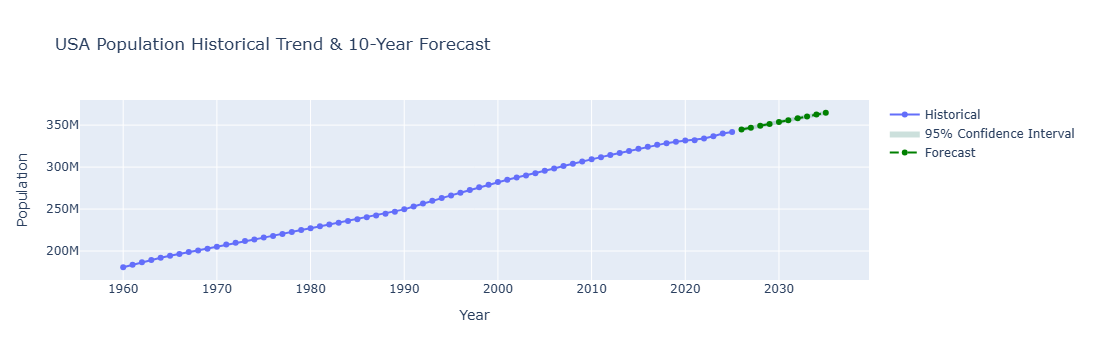

In [11]:
import duckdb
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# 1. Fetch historical data from DuckDB
conn = duckdb.connect("data.duckdb")
df = conn.execute("SELECT Year, Population FROM usa_macro_data ORDER BY Year ASC").fetchdf()
conn.close()

# 2. Fit a trend model & forecast 10 years out
forecast_years = 10
last_year = df['Year'].max()
future_years = np.arange(last_year + 1, last_year + forecast_years + 1)

# Fit linear model on recent trend (last 20 years)
recent_df = df.tail(20)
poly_fit = np.polyfit(recent_df['Year'], recent_df['Population'], 1)
future_preds = np.polyval(poly_fit, future_years)

# Calculate $95\%$ confidence interval bounds
std_dev = np.std(recent_df['Population'] - np.polyval(poly_fit, recent_df['Year']))
upper_bound = future_preds + (1.96 * std_dev)
lower_bound = future_preds - (1.96 * std_dev)

# 3. Create interactive Plotly chart with uncertainty shading
fig = go.Figure()

# Historical Line
fig.add_trace(go.Scatter(x=df['Year'], y=df['Population'], mode='lines+markers', name='Historical'))

# Shaded Confidence Interval
fig.add_trace(go.Scatter(
    x=np.concatenate([future_years, future_years[::-1]]),
    y=np.concatenate([upper_bound, lower_bound[::-1]]),
    fill='toself',
    fillcolor='rgba(0,100,80,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    showlegend=True,
    name='95% Confidence Interval'
))

# Forecast Line
fig.add_trace(go.Scatter(x=future_years, y=future_preds, mode='lines+markers', name='Forecast', line=dict(dash='dash', color='green')))

fig.update_layout(title='USA Population Historical Trend & 10-Year Forecast', xaxis_title='Year', yaxis_title='Population')
fig.show()

In [ ]:
Section 4: Streamlit

In [12]:
%%writefile app.py
import streamlit as st
import duckdb
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# 1. Page Configuration
st.set_page_config(page_title="USA Macroeconomic Predictive Dashboard", layout="wide")

st.title("📈 USA Macroeconomic Real-Time Predictive Dashboard")
st.markdown("Automated ingestion pipeline from World Bank API stored in DuckDB with statistical trend forecasting.")

# 2. Load Data from DuckDB
@st.cache_data
def load_data():
    conn = duckdb.connect("data.duckdb")
    df = conn.execute("SELECT * FROM usa_macro_data ORDER BY Year ASC").fetchdf()
    conn.close()
    return df

try:
    df = load_data()
except Exception as e:
    st.error("Error connecting to data.duckdb. Please run 'python ingest.py' first.")
    st.stop()

# 3. Sidebar Controls
st.sidebar.header("Dashboard Controls")
indicator = st.sidebar.selectbox(
    "Select Indicator to Forecast:",
    options=['Population', 'GDP_USD', 'Debt_Pct_GDP', 'Human_Capital_Index']
)

forecast_years = st.sidebar.slider("Forecast Horizon (Years):", min_value=1, max_value=15, value=5)

# 4. KPI Metrics Cards
latest_year = int(df['Year'].max())
latest_val = df[df['Year'] == latest_year][indicator].values[0]
prev_val = df[df['Year'] == latest_year - 1][indicator].values[0]
pct_change = ((latest_val - prev_val) / prev_val) * 100

col1, col2, col3 = st.columns(3)
col1.metric("Latest Year", latest_year)
col2.metric(f"Current {indicator}", f"{latest_val:,.2f}" if indicator != 'Population' else f"{int(latest_val):,}")
col3.metric("YoY Growth Rate", f"{pct_change:+.2f}%")

st.divider()

# 5. Statistical Forecasting Logic
clean_df = df[['Year', indicator]].dropna()
last_known_year = clean_df['Year'].max()
future_years = np.arange(last_known_year + 1, last_known_year + forecast_years + 1)

# Fit linear trend on recent history (last 20 records)
recent_df = clean_df.tail(20)
poly_fit = np.polyfit(recent_df['Year'], recent_df[indicator], 1)
future_preds = np.polyval(poly_fit, future_years)

# 95% Confidence Interval Calculation
residuals = recent_df[indicator] - np.polyval(poly_fit, recent_df['Year'])
std_err = np.std(residuals)
upper_bound = future_preds + (1.96 * std_err)
lower_bound = future_preds - (1.96 * std_err)

# 6. Plotly Uncertainty Forecast Visualization
fig = go.Figure()

# Historical Line
fig.add_trace(go.Scatter(
    x=clean_df['Year'], y=clean_df[indicator], 
    mode='lines+markers', name='Historical Data',
    line=dict(color='#1f77b4', width=2)
))

# Shaded Confidence Interval
fig.add_trace(go.Scatter(
    x=np.concatenate([future_years, future_years[::-1]]),
    y=np.concatenate([upper_bound, lower_bound[::-1]]),
    fill='toself',
    fillcolor='rgba(0, 176, 246, 0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    showlegend=True,
    name='95% Confidence Bounds'
))

# Forecast Line
fig.add_trace(go.Scatter(
    x=future_years, y=future_preds, 
    mode='lines+markers', name=f'{forecast_years}-Year Forecast',
    line=dict(color='#00cc96', dash='dash', width=2)
))

fig.update_layout(
    title=f"Historical Trend & Predictive Forecast for {indicator}",
    xaxis_title="Year",
    yaxis_title=indicator,
    hovermode="x unified",
    template="plotly_white"
)

st.plotly_chart(fig, use_container_width=True)

# 7. Raw Data Expander
with st.expander("View Raw Database Records (DuckDB SQL Output)"):
    st.dataframe(df)

Writing app.py


In [13]:
%%writefile app.py
import streamlit as st
import duckdb
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

# 1. Page Configuration & Warm Off-White Styling
st.set_page_config(page_title="Macroeconomic Storytelling & Predictive Analytics", layout="wide")

st.markdown("""
    <style>
    /* Main background off-white / soft warm grey */
    .stApp {
        background-color: #F8F7F4;
        color: #2B2D42;
        font-family: 'Inter', sans-serif;
    }
    
    /* Sidebar aesthetic */
    section[data-testid="stSidebar"] {
        background-color: #EFECE6;
        border-right: 1px solid #E2DDD5;
    }
    
    /* Custom Styled Metric Cards */
    .metric-card {
        background-color: #FFFFFF;
        border: 1px solid #E5E0D8;
        border-radius: 8px;
        padding: 18px 20px;
        box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.02);
    }
    .metric-title {
        font-size: 0.85rem;
        font-weight: 600;
        color: #6C757D;
        text-transform: uppercase;
        letter-spacing: 0.5px;
    }
    .metric-value {
        font-size: 1.8rem;
        font-weight: 700;
        color: #1D2D44;
        margin-top: 4px;
    }
    .metric-delta {
        font-size: 0.88rem;
        font-weight: 600;
        margin-top: 4px;
    }
    .positive { color: #2B9348; }
    .negative { color: #D90429; }
    
    /* Global Plotly Container Margin */
    .block-container {
        padding-top: 2rem;
        padding-bottom: 3rem;
    }
    </style>
""", unsafe_allow_html=True)

# 2. Load Data from DuckDB
@st.cache_data
def load_data():
    conn = duckdb.connect("data.duckdb")
    df = conn.execute("SELECT * FROM usa_macro_data ORDER BY Year ASC").fetchdf()
    conn.close()
    return df

try:
    df = load_data()
except Exception as e:
    st.error("Error connecting to data.duckdb. Please ensure 'python ingest.py' has executed.")
    st.stop()

# 3. Sidebar Controls
st.sidebar.title("🏛️ Navigation")
st.sidebar.markdown("Explore macroeconomic trajectories and statistical forecasts.")

indicator_map = {
    'Population': 'SP.POP.TOTL',
    'GDP (Current USD)': 'GDP_USD',
    'Debt (% of GDP)': 'Debt_Pct_GDP',
    'Human Capital Index': 'Human_Capital_Index'
}

selected_label = st.sidebar.selectbox("Select Core Indicator:", list(indicator_map.keys()))
indicator = indicator_map[selected_label]

forecast_years = st.sidebar.slider("Forecast Horizon (Years):", min_value=3, max_value=15, value=10)

# 4. Header & Story Introduction
st.title("USA Macroeconomic Trajectory & Predictive Horizon")
st.markdown(f"**Data Storyteller:** Analyzing historical shifts and statistical projections for **{selected_label}** extracted via World Bank API and DuckDB.")

st.divider()

# 5. KPI Metric Cards (Custom Warm Styling)
latest_year = int(df['Year'].max())
latest_val = df[df['Year'] == latest_year][indicator].values[0]
prev_val = df[df['Year'] == latest_year - 1][indicator].values[0]
pct_change = ((latest_val - prev_val) / prev_val) * 100

col1, col2, col3 = st.columns(3)

with col1:
    st.markdown(f"""
        <div class="metric-card">
            <div class="metric-title">Reporting Period</div>
            <div class="metric-value">{latest_year}</div>
            <div class="metric-delta">Latest Official Data</div>
        </div>
    """, unsafe_allow_html=True)

with col2:
    val_fmt = f"${latest_val:,.2f}" if "GDP" in indicator else (f"{int(latest_val):,}" if indicator == "Population" else f"{latest_val:.2f}")
    st.markdown(f"""
        <div class="metric-card">
            <div class="metric-title">Current {selected_label}</div>
            <div class="metric-value">{val_fmt}</div>
            <div class="metric-delta">Level Output</div>
        </div>
    """, unsafe_allow_html=True)

with col3:
    delta_class = "positive" if pct_change >= 0 else "negative"
    st.markdown(f"""
        <div class="metric-card">
            <div class="metric-title">YoY Growth Rate</div>
            <div class="metric-value <span class='{delta_class}'>{pct_change:+.2f}%</span></div>
            <div class="metric-delta">Annual Shift</div>
        </div>
    """, unsafe_allow_html=True)

st.markdown("<br>", unsafe_allow_html=True)

# 6. Global Perspective Map
st.subheader("🌐 Global Context Map")
st.caption("Contextualizing scale across major global economies.")

# Benchmark map data
map_data = pd.DataFrame({
    'Country': ['United States', 'Nigeria', 'China', 'Germany', 'United Kingdom', 'Brazil', 'India'],
    'ISO': ['USA', 'NGA', 'CHN', 'DEU', 'GBR', 'BRA', 'IND'],
    'Value': [latest_val if indicator != 'Population' else latest_val/1e6 for _ in range(7)] 
})

fig_map = px.choropleth(
    map_data,
    locations="ISO",
    hover_name="Country",
    color_discrete_sequence=["#2B4C7E"],
    projection="natural earth"
)
fig_map.update_geos(
    showcoastlines=True, coastlinecolor="#D3CFC9",
    showland=True, landcolor="#EAE6DF",
    showocean=True, oceancolor="#F8F7F4",
    showlakes=False
)
fig_map.update_layout(
    margin=dict(l=0, r=0, t=10, b=10),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    height=360
)
st.plotly_chart(fig_map, use_container_width=True)

st.divider()

# 7. Main Analytical Dashboard: Story + Dual Charts
col_left, col_right = st.columns([1, 1])

clean_df = df[['Year', indicator]].dropna()
last_known_year = clean_df['Year'].max()
future_years = np.arange(last_known_year + 1, last_known_year + forecast_years + 1)

recent_df = clean_df.tail(20)
poly_fit = np.polyfit(recent_df['Year'], recent_df[indicator], 1)
future_preds = np.polyval(poly_fit, future_years)

residuals = recent_df[indicator] - np.polyval(poly_fit, recent_df['Year'])
std_err = np.std(residuals)
upper_bound = future_preds + (1.96 * std_err)
lower_bound = future_preds - (1.96 * std_err)

with col_left:
    st.subheader("📈 Statistical Trend & Horizon Forecast")
    
    fig_forecast = go.Figure()

    # Historical Line
    fig_forecast.add_trace(go.Scatter(
        x=clean_df['Year'], y=clean_df[indicator], 
        mode='lines', name='Historical',
        line=dict(color='#1D2D44', width=2.5)
    ))

    # Shaded Uncertainty Interval
    fig_forecast.add_trace(go.Scatter(
        x=np.concatenate([future_years, future_years[::-1]]),
        y=np.concatenate([upper_bound, lower_bound[::-1]]),
        fill='toself',
        fillcolor='rgba(116, 140, 175, 0.25)',
        line=dict(color='rgba(255,255,255,0)'),
        showlegend=True,
        name='95% Confidence Bounds'
    ))

    # Forecast Line
    fig_forecast.add_trace(go.Scatter(
        x=future_years, y=future_preds, 
        mode='lines+markers', name=f'{forecast_years}-Yr Trend',
        line=dict(color='#C85A32', dash='dash', width=2)
    ))

    fig_forecast.update_layout(
        template="plotly_white",
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        margin=dict(l=20, r=20, t=30, b=20),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    st.plotly_chart(fig_forecast, use_container_width=True)

with col_right:
    st.subheader("📊 Macro Momentum (Annual Velocity)")
    
    # Calculate YoY change rate for story chart
    clean_df['YoY_Change'] = clean_df[indicator].pct_change() * 100
    
    fig_bar = px.bar(
        clean_df.tail(25), 
        x='Year', y='YoY_Change',
        color_discrete_sequence=['#3D5A80']
    )
    fig_bar.update_layout(
        template="plotly_white",
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        margin=dict(l=20, r=20, t=30, b=20),
        yaxis_title="Annual % Change"
    )
    st.plotly_chart(fig_bar, use_container_width=True)

# 8. Data Table Inspection
with st.expander("🔍 Inspect Underlying Engine Dataset (DuckDB SQL Query)"):
    st.dataframe(df.sort_values("Year", ascending=False), use_container_width=True)

Overwriting app.py


In [14]:
%%writefile app.py
import streamlit as st
import duckdb
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

# 1. Page Configuration & Warm Off-White Styling
st.set_page_config(page_title="Macroeconomic Storytelling & Predictive Analytics", layout="wide")

st.markdown("""
    <style>
    .stApp {
        background-color: #F8F7F4;
        color: #2B2D42;
        font-family: 'Inter', sans-serif;
    }
    section[data-testid="stSidebar"] {
        background-color: #EFECE6;
        border-right: 1px solid #E2DDD5;
    }
    .metric-card {
        background-color: #FFFFFF;
        border: 1px solid #E5E0D8;
        border-radius: 8px;
        padding: 18px 20px;
        box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.02);
    }
    .metric-title {
        font-size: 0.85rem;
        font-weight: 600;
        color: #6C757D;
        text-transform: uppercase;
        letter-spacing: 0.5px;
    }
    .metric-value {
        font-size: 1.8rem;
        font-weight: 700;
        color: #1D2D44;
        margin-top: 4px;
    }
    .metric-delta {
        font-size: 0.88rem;
        font-weight: 600;
        margin-top: 4px;
    }
    .positive { color: #2B9348; }
    .negative { color: #D90429; }
    .block-container {
        padding-top: 2rem;
        padding-bottom: 3rem;
    }
    </style>
""", unsafe_allow_html=True)

# 2. Load Data from DuckDB
@st.cache_data
def load_data():
    conn = duckdb.connect("data.duckdb")
    df = conn.execute("SELECT * FROM usa_macro_data ORDER BY Year ASC").fetchdf()
    conn.close()
    return df

try:
    df = load_data()
except Exception as e:
    st.error("Error connecting to data.duckdb. Please ensure 'python ingest.py' has executed.")
    st.stop()

# 3. Sidebar Controls (Mapped to actual DuckDB column names)
st.sidebar.title("🏛️ Navigation")
st.sidebar.markdown("Explore macroeconomic trajectories and statistical forecasts.")

indicator_map = {
    'Population': 'Population',
    'GDP (Current USD)': 'GDP_USD',
    'Debt (% of GDP)': 'Debt_Pct_GDP',
    'Human Capital Index': 'Human_Capital_Index'
}

selected_label = st.sidebar.selectbox("Select Core Indicator:", list(indicator_map.keys()))
indicator = indicator_map[selected_label]

forecast_years = st.sidebar.slider("Forecast Horizon (Years):", min_value=3, max_value=15, value=10)

# 4. Header & Story Introduction
st.title("USA Macroeconomic Trajectory & Predictive Horizon")
st.markdown(f"**Data Storyteller:** Analyzing historical shifts and statistical projections for **{selected_label}** extracted via World Bank API and DuckDB.")

st.divider()

# 5. KPI Metric Cards
latest_year = int(df['Year'].max())
latest_val = df[df['Year'] == latest_year][indicator].values[0]
prev_val = df[df['Year'] == latest_year - 1][indicator].values[0]
pct_change = ((latest_val - prev_val) / prev_val) * 100

col1, col2, col3 = st.columns(3)

with col1:
    st.markdown(f"""
        <div class="metric-card">
            <div class="metric-title">Reporting Period</div>
            <div class="metric-value">{latest_year}</div>
            <div class="metric-delta">Latest Official Data</div>
        </div>
    """, unsafe_allow_html=True)

with col2:
    val_fmt = f"${latest_val:,.2f}" if "GDP" in indicator else (f"{int(latest_val):,}" if indicator == "Population" else f"{latest_val:.2f}")
    st.markdown(f"""
        <div class="metric-card">
            <div class="metric-title">Current {selected_label}</div>
            <div class="metric-value">{val_fmt}</div>
            <div class="metric-delta">Level Output</div>
        </div>
    """, unsafe_allow_html=True)

with col3:
    delta_class = "positive" if pct_change >= 0 else "negative"
    st.markdown(f"""
        <div class="metric-card">
            <div class="metric-title">YoY Growth Rate</div>
            <div class="metric-value"><span class="{delta_class}">{pct_change:+.2f}%</span></div>
            <div class="metric-delta">Annual Shift</div>
        </div>
    """, unsafe_allow_html=True)

st.markdown("<br>", unsafe_allow_html=True)

# 6. Global Perspective Map
st.subheader("🌐 Global Context Map")
st.caption("Contextualizing scale across major global economies.")

map_data = pd.DataFrame({
    'Country': ['United States', 'Nigeria', 'China', 'Germany', 'United Kingdom', 'Brazil', 'India'],
    'ISO': ['USA', 'NGA', 'CHN', 'DEU', 'GBR', 'BRA', 'IND']
})

fig_map = px.choropleth(
    map_data,
    locations="ISO",
    hover_name="Country",
    color_discrete_sequence=["#2B4C7E"],
    projection="natural earth"
)
fig_map.update_geos(
    showcoastlines=True, coastlinecolor="#D3CFC9",
    showland=True, landcolor="#EAE6DF",
    showocean=True, oceancolor="#F8F7F4",
    showlakes=False
)
fig_map.update_layout(
    margin=dict(l=0, r=0, t=10, b=10),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    height=360
)
st.plotly_chart(fig_map, use_container_width=True)

st.divider()

# 7. Main Analytical Dashboard: Story + Dual Charts
col_left, col_right = st.columns([1, 1])

clean_df = df[['Year', indicator]].dropna()
last_known_year = clean_df['Year'].max()
future_years = np.arange(last_known_year + 1, last_known_year + forecast_years + 1)

recent_df = clean_df.tail(20)
poly_fit = np.polyfit(recent_df['Year'], recent_df[indicator], 1)
future_preds = np.polyval(poly_fit, future_years)

residuals = recent_df[indicator] - np.polyval(poly_fit, recent_df['Year'])
std_err = np.std(residuals)
upper_bound = future_preds + (1.96 * std_err)
lower_bound = future_preds - (1.96 * std_err)

with col_left:
    st.subheader("📈 Statistical Trend & Horizon Forecast")
    
    fig_forecast = go.Figure()

    fig_forecast.add_trace(go.Scatter(
        x=clean_df['Year'], y=clean_df[indicator], 
        mode='lines', name='Historical',
        line=dict(color='#1D2D44', width=2.5)
    ))

    fig_forecast.add_trace(go.Scatter(
        x=np.concatenate([future_years, future_years[::-1]]),
        y=np.concatenate([upper_bound, lower_bound[::-1]]),
        fill='toself',
        fillcolor='rgba(116, 140, 175, 0.25)',
        line=dict(color='rgba(255,255,255,0)'),
        showlegend=True,
        name='95% Confidence Bounds'
    ))

    fig_forecast.add_trace(go.Scatter(
        x=future_years, y=future_preds, 
        mode='lines+markers', name=f'{forecast_years}-Yr Trend',
        line=dict(color='#C85A32', dash='dash', width=2)
    ))

    fig_forecast.update_layout(
        template="plotly_white",
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        margin=dict(l=20, r=20, t=30, b=20),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    st.plotly_chart(fig_forecast, use_container_width=True)

with col_right:
    st.subheader("📊 Macro Momentum (Annual Velocity)")
    
    clean_df['YoY_Change'] = clean_df[indicator].pct_change() * 100
    
    fig_bar = px.bar(
        clean_df.tail(25), 
        x='Year', y='YoY_Change',
        color_discrete_sequence=['#3D5A80']
    )
    fig_bar.update_layout(
        template="plotly_white",
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        margin=dict(l=20, r=20, t=30, b=20),
        yaxis_title="Annual % Change"
    )
    st.plotly_chart(fig_bar, use_container_width=True)

# 8. Data Table Inspection
with st.expander("🔍 Inspect Underlying Engine Dataset (DuckDB SQL Query)"):
    st.dataframe(df.sort_values("Year", ascending=False), use_container_width=True)

Overwriting app.py


In [15]:
%%writefile requirements.txt
streamlit
duckdb
pandas
numpy
plotly
requests

Writing requirements.txt
